<a href="https://colab.research.google.com/github/sahilshirsat2004-coder/CSL701-CE45_Machine-Learning-Lab/blob/main/EXPERIMENT/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Sahil Ganesh Shirsat

Batch : CE3


Roll Number : CE45



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Get uploaded filename automatically
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)

# Display first 5 rows
display(df.head())

print("Dataset loaded successfully!")
print("File Name:", filename)


Saving brca.csv to brca.csv


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


Dataset loaded successfully!
File Name: brca.csv


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Dataset Shape: (569, 32)

Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Data Types:
Unnamed: 0               int64
x.radius_mean          float64
x.texture_mean         float64
x.perimeter_mean       float64
x.area_mean            float64
x.smoothness_mean      float64
x.compactness_mean     float64
x.concavity_mean       float64
x.concave_pts_mean     float64
x.symmetry_mean        float64
x.fractal_dim_mean     float64
x.radius

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Diagnosis Distribution:
y
B    357
M    212
Name: count, dtype: int64


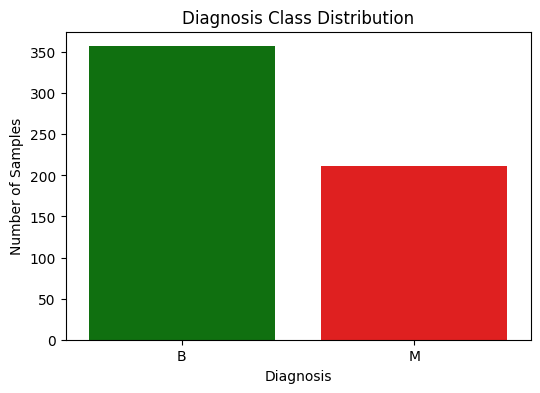

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Task 2: Explore the Dataset

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Check diagnosis distribution
print("\nDiagnosis Distribution:")
print(df["y"].value_counts()) # Changed 'diagnosis' to 'y'

# Visualize diagnosis distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x="y", # Changed 'diagnosis' to 'y'
    data=df,
    hue="y", # Changed 'diagnosis' to 'y'
    palette=["green", "red"],
    legend=False
)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Task 3: Preprocess and Scale Features

# Make a copy of the dataset
df_clean = df.copy()

# Drop non-informative columns if they exist
columns_to_drop = ["id", "Unnamed: 32"]

for column in columns_to_drop:
    if column in df_clean.columns:
        df_clean.drop(column, axis=1, inplace=True)

# Convert diagnosis into numerical labels
# Malignant = 1
# Benign = 0

df_clean["y"] = df_clean["y"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = df_clean.drop("y", axis=1)
y = df_clean["y"]

# Make sure all feature columns are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Handle any missing values
X = X.fillna(X.median())

# StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Original Feature Shape:", X.shape)
print("Scaled Feature Shape:", X_scaled.shape)

print("\nFirst 5 rows after scaling:")
display(X_scaled_df.head())
# Check mean and standard deviation

print("Mean of scaled features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of scaled features:")
print(X_scaled_df.std().round(2))

Original Feature Shape: (569, 31)
Scaled Feature Shape: (569, 31)

First 5 rows after scaling:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-1.729009,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-1.722921,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.716833,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-1.710745,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.704657,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


Mean of scaled features:
Unnamed: 0             0.0
x.radius_mean         -0.0
x.texture_mean        -0.0
x.perimeter_mean      -0.0
x.area_mean           -0.0
x.smoothness_mean      0.0
x.compactness_mean     0.0
x.concavity_mean       0.0
x.concave_pts_mean     0.0
x.symmetry_mean        0.0
x.fractal_dim_mean     0.0
x.radius_se            0.0
x.texture_se          -0.0
x.perimeter_se         0.0
x.area_se             -0.0
x.smoothness_se       -0.0
x.compactness_se       0.0
x.concavity_se        -0.0
x.concave_pts_se       0.0
x.symmetry_se          0.0
x.fractal_dim_se      -0.0
x.radius_worst        -0.0
x.texture_worst        0.0
x.perimeter_worst      0.0
x.area_worst          -0.0
x.smoothness_worst    -0.0
x.compactness_worst    0.0
x.concavity_worst      0.0
x.concave_pts_worst    0.0
x.symmetry_worst       0.0
x.fractal_dim_worst    0.0
dtype: float64

Standard deviation of scaled features:
Unnamed: 0             1.0
x.radius_mean          1.0
x.texture_mean         1.0
x.

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Task 4: Construct Pairwise Distance Matrix & Graph

# Calculate pairwise Euclidean distances
distance_vector = pdist(
    X_scaled,
    metric="euclidean"
)

# Convert condensed distance matrix to square matrix
distance_matrix = squareform(distance_vector)

print("Distance Matrix Shape:", distance_matrix.shape)

# Display a small portion of the distance matrix
print("\nFirst 5 x 5 Distance Matrix:")
print(distance_matrix[:5, :5])
# Create complete weighted graph

G = nx.Graph()

# Add nodes
num_samples = X_scaled.shape[0]

G.add_nodes_from(range(num_samples))

# Add weighted edges
for i in range(num_samples):
    for j in range(i + 1, num_samples):
        G.add_edge(
            i,
            j,
            weight=distance_matrix[i, j]
        )

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())


Distance Matrix Shape: (569, 569)

First 5 x 5 Distance Matrix:
[[0.         3.10725264 3.62316224 5.20451369 4.46715199]
 [3.10725264 0.         4.01028047 5.62303335 4.37102093]
 [3.62316224 4.01028047 0.         5.12193953 2.94842089]
 [5.20451369 5.62303335 5.12193953 0.         5.02799161]
 [4.46715199 4.37102093 2.94842089 5.02799161 0.        ]]
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute Minimum Spanning Tree

# Compute MST from distance matrix
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert MST to dense matrix
mst_matrix = mst_sparse.toarray()

# Number of MST edges
mst_edges = np.count_nonzero(mst_matrix)

print("Number of Samples:", num_samples)
print("Number of MST Edges:", mst_edges)
# Extract MST edges

mst_edge_list = []

for i in range(num_samples):
    for j in range(num_samples):
        if mst_matrix[i, j] > 0:
            mst_edge_list.append(
                (i, j, mst_matrix[i, j])
            )

# Convert to DataFrame
mst_edges_df = pd.DataFrame(
    mst_edge_list,
    columns=["Node1", "Node2", "Weight"]
)

# Sort by edge weight
mst_edges_df = mst_edges_df.sort_values(
    by="Weight",
    ascending=False
)

print("MST Edge Information:")
display(mst_edges_df.head(10))


Number of Samples: 569
Number of MST Edges: 568
MST Edge Information:


,Node1,Node2,Weight
564,544,553,12.300067
24,18,69,10.480675
515,468,527,9.042305
514,467,544,8.281820
463,424,429,8.078042
369,360,454,7.891816
25,18,208,7.876494
447,412,515,7.117204
502,454,515,7.072387
385,369,395,6.970796


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Graph-Based Clustering (K=2)

# Copy MST matrix
mst_for_clustering = mst_matrix.copy()

# Find the largest MST edge
largest_edge_index = np.unravel_index(
    np.argmax(mst_for_clustering),
    mst_for_clustering.shape
)

node1 = largest_edge_index[0]
node2 = largest_edge_index[1]

largest_weight = mst_for_clustering[
    node1,
    node2
]

print("Largest MST Edge:")
print("Node 1:", node1)
print("Node 2:", node2)
print("Edge Weight:", largest_weight)
# Remove the largest edge

mst_for_clustering[node1, node2] = 0
mst_for_clustering[node2, node1] = 0

# Convert to NetworkX graph
cluster_graph = nx.from_numpy_array(
    mst_for_clustering
)

# Find connected components
components = list(
    nx.connected_components(cluster_graph)
)

print("Number of Clusters:", len(components))

for i, component in enumerate(components):
    print(
        f"Cluster {i}: {len(component)} samples"
    )
# Assign cluster labels

cluster_labels = np.zeros(
    num_samples,
    dtype=int
)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("\nCluster Labels:")
print(cluster_labels[:20])

print("\nCluster Distribution:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)


Largest MST Edge:
Node 1: 544
Node 2: 553
Edge Weight: 12.300067427372793
Number of Clusters: 2
Cluster 0: 567 samples
Cluster 1: 2 samples

Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Cluster Distribution:
0    567
1      2
Name: count, dtype: int64


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance

# Silhouette Score
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

# Adjusted Rand Index
ari = adjusted_rand_score(
    y,
    cluster_labels
)

# Normalized Mutual Information
nmi = normalized_mutual_info_score(
    y,
    cluster_labels
)

print("===== MST CLUSTERING PERFORMANCE =====")

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
# Compare actual labels and cluster labels

comparison_df = pd.DataFrame({
    "Actual Diagnosis": y.values,
    "MST Cluster": cluster_labels
})

display(
    pd.crosstab(
        comparison_df["Actual Diagnosis"],
        comparison_df["MST Cluster"]
    )
)


===== MST CLUSTERING PERFORMANCE =====
Silhouette Score: 0.6547
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


MST Cluster,0,1
Actual Diagnosis,,
0,357,0
1,210,2


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

Available feature columns:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst']
X-axis Feature: x.radius_mean
Y-axis Feature: x.texture_mean


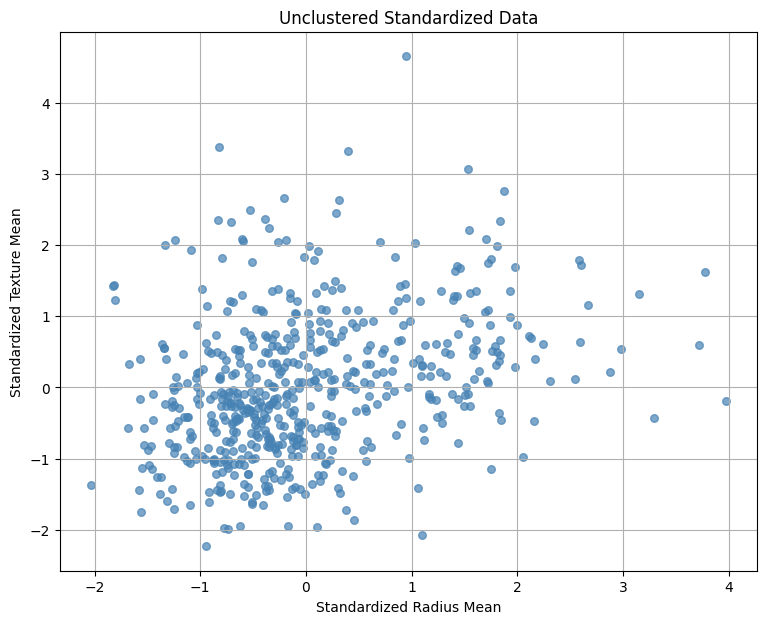

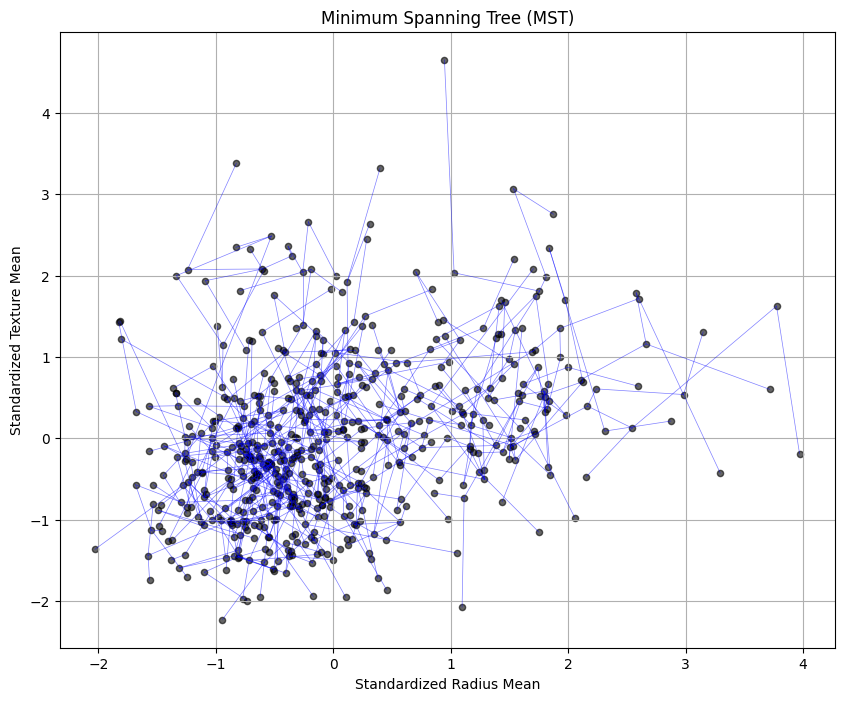

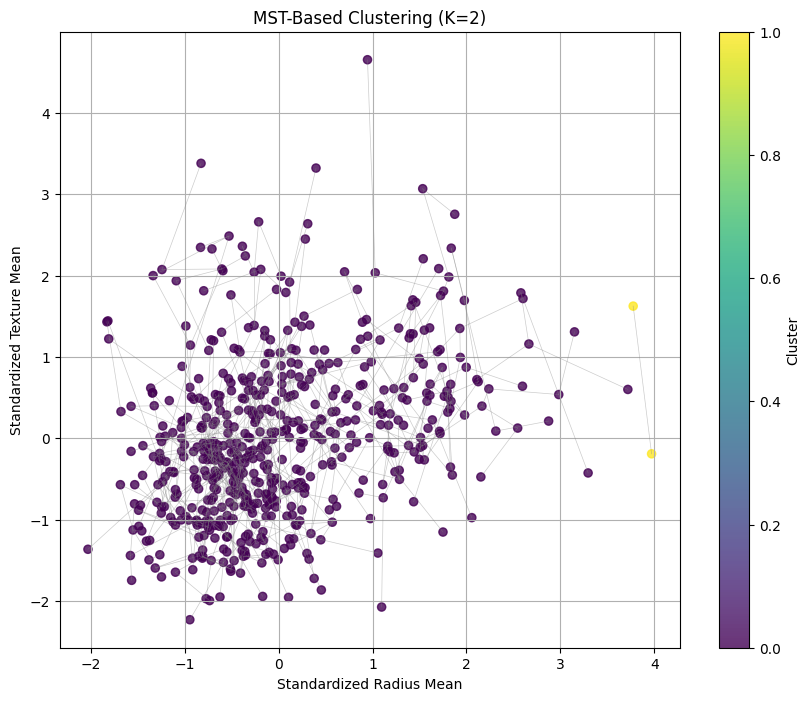

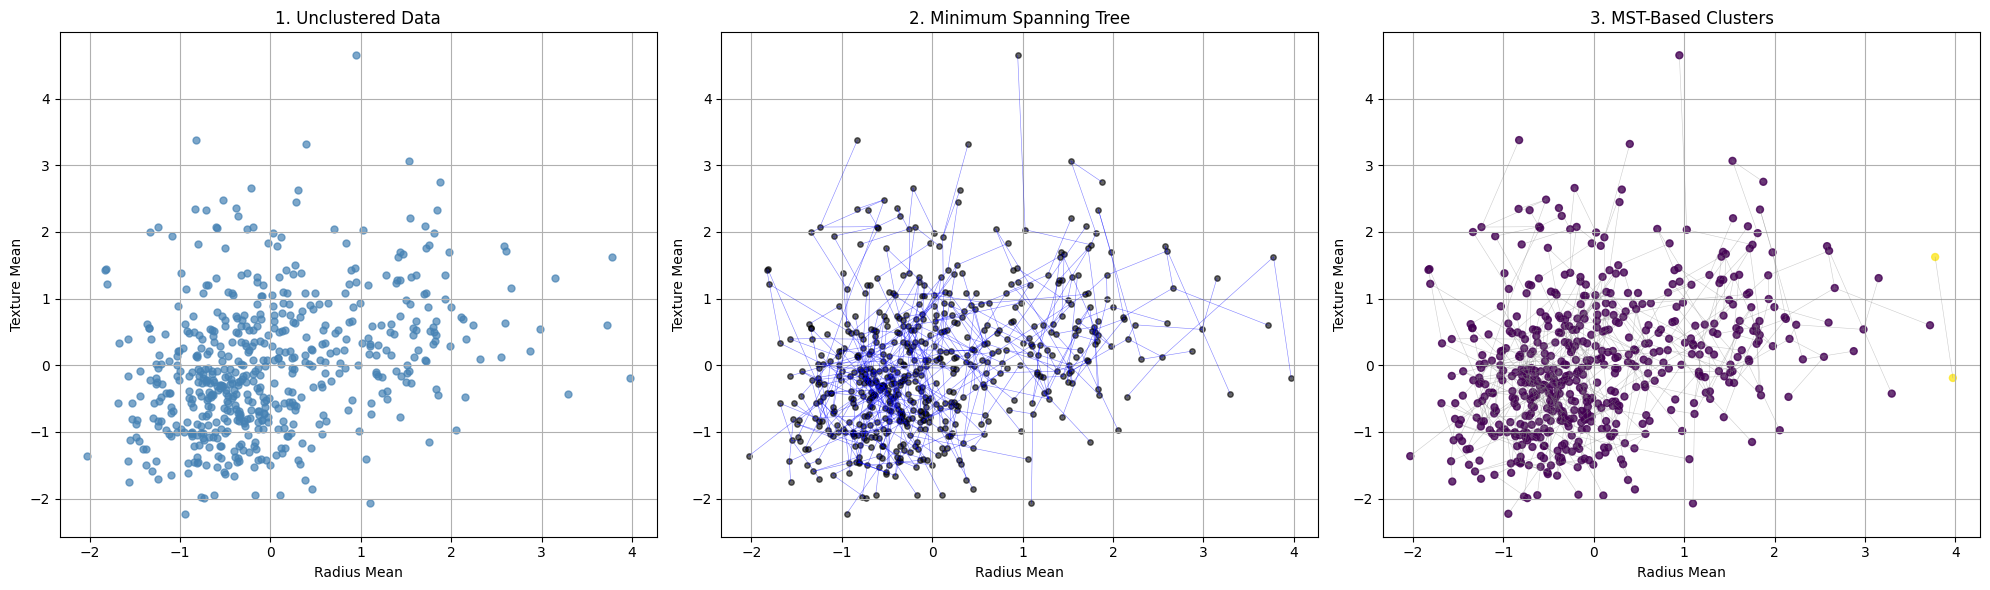

,Metric,Value
0,Number of Samples,569.0000
1,Number of Features,31.0000
2,Number of Clusters,2.0000
3,Silhouette Score,0.6547
4,Adjusted Rand Index (ARI),0.0048
5,Normalized Mutual Information (NMI),0.0102


In [ ]:
# Task 8: Select two representative features

print("Available feature columns:")
print(X.columns.tolist())
# Select two representative features

feature_x = "x.radius_mean"
feature_y = "x.texture_mean"

# Get column indices
x_index = X.columns.get_loc(feature_x)
y_index = X.columns.get_loc(feature_y)

# Extract standardized values
plot_x = X_scaled[:, x_index]
plot_y = X_scaled[:, y_index]

print("X-axis Feature:", feature_x)
print("Y-axis Feature:", feature_y)# Plot 1: Unclustered standardized data

plt.figure(figsize=(9, 7))

plt.scatter(
    plot_x,
    plot_y,
    color="steelblue",
    alpha=0.7,
    s=30
)

plt.title("Unclustered Standardized Data")
plt.xlabel("Standardized Radius Mean")
plt.ylabel("Standardized Texture Mean")
plt.grid(True)

plt.show()
# Plot 2: MST Edge Connections

plt.figure(figsize=(10, 8))

# Plot all data points
plt.scatter(
    plot_x,
    plot_y,
    color="black",
    s=20,
    alpha=0.6
)

# Draw MST edges
for node1, node2, weight in mst_edge_list:

    plt.plot(
        [plot_x[node1], plot_x[node2]],
        [plot_y[node1], plot_y[node2]],
        color="blue",
        linewidth=0.5,
        alpha=0.5
    )

plt.title("Minimum Spanning Tree (MST)")
plt.xlabel("Standardized Radius Mean")
plt.ylabel("Standardized Texture Mean")
plt.grid(True)

plt.show()
# Plot 3: Final MST-Based Clusters

plt.figure(figsize=(10, 8))

# Plot clusters
scatter = plt.scatter(
    plot_x,
    plot_y,
    c=cluster_labels,
    cmap="viridis",
    s=35,
    alpha=0.8
)

# Draw MST edges
for node1, node2, weight in mst_edge_list:

    # Do not draw the removed largest edge
    if (
        (node1 == largest_edge_index[0] and node2 == largest_edge_index[1])
        or
        (node1 == largest_edge_index[1] and node2 == largest_edge_index[0])
    ):
        continue

    plt.plot(
        [plot_x[node1], plot_x[node2]],
        [plot_y[node1], plot_y[node2]],
        color="gray",
        linewidth=0.5,
        alpha=0.4
    )

plt.title("MST-Based Clustering (K=2)")
plt.xlabel("Standardized Radius Mean")
plt.ylabel("Standardized Texture Mean")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)
plt.show()
# Display all three plots together

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

# -------------------------------
# Plot 1: Unclustered Data
# -------------------------------

axes[0].scatter(
    plot_x,
    plot_y,
    color="steelblue",
    s=25,
    alpha=0.7
)

axes[0].set_title("1. Unclustered Data")
axes[0].set_xlabel("Radius Mean")
axes[0].set_ylabel("Texture Mean")
axes[0].grid(True)


# -------------------------------
# Plot 2: MST
# -------------------------------

axes[1].scatter(
    plot_x,
    plot_y,
    color="black",
    s=15,
    alpha=0.6
)

for node1, node2, weight in mst_edge_list:
    axes[1].plot(
        [plot_x[node1], plot_x[node2]],
        [plot_y[node1], plot_y[node2]],
        color="blue",
        linewidth=0.4,
        alpha=0.5
    )

axes[1].set_title("2. Minimum Spanning Tree")
axes[1].set_xlabel("Radius Mean")
axes[1].set_ylabel("Texture Mean")
axes[1].grid(True)


# -------------------------------
# Plot 3: Final Clusters
# -------------------------------

scatter = axes[2].scatter(
    plot_x,
    plot_y,
    c=cluster_labels,
    cmap="viridis",
    s=25,
    alpha=0.8
)

for node1, node2, weight in mst_edge_list:

    if (
        (node1 == largest_edge_index[0] and node2 == largest_edge_index[1])
        or
        (node1 == largest_edge_index[1] and node2 == largest_edge_index[0])
    ):
        continue

    axes[2].plot(
        [plot_x[node1], plot_x[node2]],
        [plot_y[node1], plot_y[node2]],
        color="gray",
        linewidth=0.4,
        alpha=0.4
    )

axes[2].set_title("3. MST-Based Clusters")
axes[2].set_xlabel("Radius Mean")
axes[2].set_ylabel("Texture Mean")
axes[2].grid(True)

plt.tight_layout()
plt.show()
# Final Results Summary

results = pd.DataFrame({
    "Metric": [
        "Number of Samples",
        "Number of Features",
        "Number of Clusters",
        "Silhouette Score",
        "Adjusted Rand Index (ARI)",
        "Normalized Mutual Information (NMI)"
    ],
    "Value": [
        X.shape[0],
        X.shape[1],
        len(components),
        round(silhouette, 4),
        round(ari, 4),
        round(nmi, 4)
    ]
})

display(results)


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.